# Minimal Model length scales: theory vs PDE

Combines `MM 2 - length scales theory.ipynb` and `MM 3 - PDEs biomass.ipynb`.

1. Plot the theoretical pattern wavelength $L = 2\pi/\sqrt{k_*^2}$ as a function of $\beta = K c / (m r)$, using `fr2_km2`.
2. Run a 1D PDE from a near-steady-state plus small perturbation for a handful of $(K, l, p)$ values.
3. Measure the dominant wavelength of $N(x)$ at the final time via FFT and scatter against theory.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--', 'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

from ssmc.minimal_model import MMParams, mm_get_nospace_sol, mmp_to_smicrm
from ssmc.analytics import fr2_beta_lb, fr2_beta_ub, fr2_instab_beta_range, fr2_km2, ksquared_to_L
from ssmc.solver import solve_pde

## 1. Theoretical length scale $L_*(\beta)$

For a fixed leakage $l$ and diffusion ratio $p$, sweep $\beta$ across the instability range and convert $k_*^2$ to a wavelength.

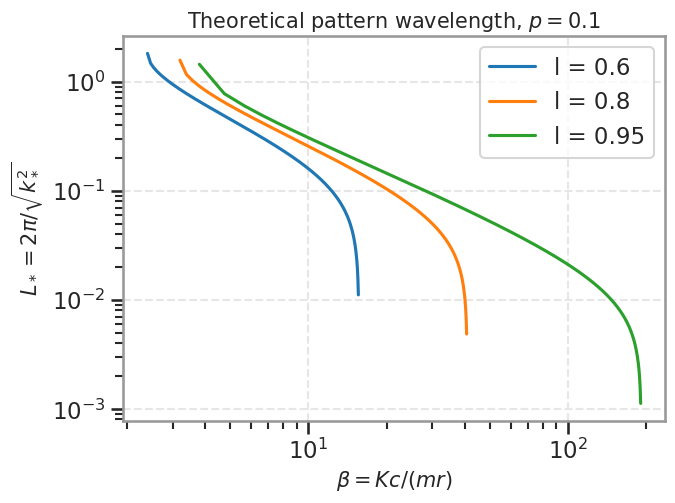

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for l in [0.6, 0.8, 0.95]:
    p = 0.1
    betas = fr2_instab_beta_range(l, p, 200)
    if betas.size == 0:
        continue
    k2 = np.array([fr2_km2(b, l, p, r_over_D=1.0) for b in betas])
    L = np.array([ksquared_to_L(k) for k in k2])
    ax.plot(betas, L, label=f"l = {l}")
ax.set_xlabel(r"$\beta = K c / (m r)$")
ax.set_ylabel(r"$L_* = 2\pi/\sqrt{k_*^2}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Theoretical pattern wavelength, $p = 0.1$")
ax.legend()
plt.show()

## 2. PDE simulation

We simulate the spatial Minimal Model from a perturbed steady state on a periodic domain and read off the dominant wavelength from the final-time FFT of $N(x)$.

In [4]:
def run_pde_and_measure_L(K, l, p, ssize=512, L_box=200.0, t_max=200.0, seed=0):
    mmp = MMParams(K=K, m=1.0, c=1.0, l=l)
    sols = [s for s in mm_get_nospace_sol(mmp) if s[0] > 1e-8]
    if not sols:
        return None
    sols.sort(key=lambda s: s[0], reverse=True)
    ss = sols[0]

    dx = L_box / ssize
    sparams = mmp_to_smicrm(mmp, DN=1e-12, DI=1.0, DR=p, dx=dx, bc="periodic")
    rng = np.random.default_rng(seed)
    u0 = np.tile(ss[:, None], (1, ssize)) * (1.0 + 1e-3 * rng.standard_normal((3, ssize)))

    pde = solve_pde(sparams, u0, t_span=(0.0, t_max), t_eval=np.array([0.0, t_max]), rtol=1e-6, atol=1e-9)
    if not pde.success:
        return None

    N_final = pde.u[-1, 0, :] - ss[0]
    spec = np.abs(np.fft.rfft(N_final))
    spec[0] = 0.0
    j_peak = int(np.argmax(spec))
    if j_peak == 0:
        return None
    k_meas = 2 * np.pi * j_peak / L_box
    L_meas = 2 * np.pi / k_meas

    k2_th = fr2_km2(beta=K * 1.0 / (1.0 * 1.0), l=l, p=p, r_over_D=1.0)
    L_th = ksquared_to_L(k2_th)
    return L_meas, L_th, pde, ss, dx

In [10]:
def cases_near_threshold(l, p, n=4, frac_lo=0.1, frac_hi=0.6, beta_cap=20.0):
    #"""Pick beta values fractionally above the lower instability bound — wavelengths stay finite."""
    lb = fr2_beta_lb(l)
    ub = min(fr2_beta_ub(l, p), beta_cap)
    if ub <= lb:
        return []
    return [(b, l, p) for b in np.linspace(lb + frac_lo * (ub - lb), lb + frac_hi * (ub - lb), n)]

cases = cases_near_threshold(l=0.6, p=0.5, n=10) + cases_near_threshold(l=0.7, p=0.5, n=10)

results = []
for K, l, p in cases:
    out = run_pde_and_measure_L(K, l, p, ssize=512, L_box=20.0, t_max=200.0)
    if out is None:
        continue
    L_meas, L_th, *_ = out
    results.append((K, l, p, L_meas, L_th))

results = np.array(results)
print(f"ran {len(results)} cases")

ran 20 cases


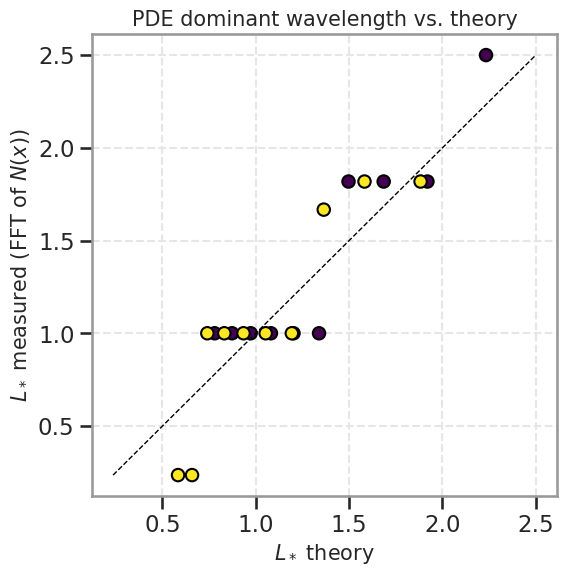

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(results[:, 4], results[:, 3], c=results[:, 1], cmap='viridis', s=80, edgecolor='k')
lo = np.nanmin(results[:, 3:5])
hi = np.nanmax(results[:, 3:5])
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
ax.set_xlabel(r"$L_*$ theory")
ax.set_ylabel(r"$L_*$ measured (FFT of $N(x)$)")
ax.set_title("PDE dominant wavelength vs. theory")
plt.show()

## 3. Snapshot for one case

In [ ]:
K, l, p = cases[0]
out = run_pde_and_measure_L(K=K, l=l, p=p, ssize=512, L_box=20.0, t_max=200.0)
L_meas, L_th, pde, ss, dx = out
x = np.arange(pde.u.shape[2]) * dx

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, pde.u[-1, 0, :], label='N(x)')
ax.plot(x, pde.u[-1, 1, :], label='I(x)', linestyle='--')
ax.plot(x, pde.u[-1, 2, :], label='R(x)', linestyle=':')
ax.set_xlabel('x')
ax.set_ylabel('concentration')
ax.set_title(f"K={K:.2f}, l={l}, p={p}  —  L_meas={L_meas:.2f}, L_theory={L_th:.2f}")
ax.legend()
plt.show()